<a href="https://colab.research.google.com/github/Farhana-Tani/Papaya-leaf-disease-detection/blob/main/Papaya_Leaf_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install opencv-python-headless scikit-learn seaborn pandas matplotlib pillow
import os, random, math, json, zipfile, shutil, glob, time
from pathlib import Path
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score)
SEED=42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
seed_everything()
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE, '| PyTorch:', torch.__version__)

Device: cuda | PyTorch: 2.11.0+cu128


In [6]:
from pathlib import Path
import zipfile

# ZIP file already uploaded to Colab Files
archive_path = Path("/content/BDPapayaLeaf.zip")

# Extract dataset
extract_root = Path("/content/BDPapayaLeaf")

if not archive_path.exists():
    raise FileNotFoundError(
        f"{archive_path} not found. Make sure BDPapayaLeaf.zip is uploaded "
        "to the Colab Files panel."
    )

extract_root.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(archive_path, "r") as z:
    z.extractall(extract_root)

SEARCH_ROOT = extract_root

print("Dataset extracted to:", SEARCH_ROOT)

Dataset extracted to: /content/BDPapayaLeaf


In [8]:
CLASS_NAMES=['Anthracnose','Bacterial Spot','Curl','Ring Spot','Healthy']
def norm_name(s): return ''.join(ch for ch in s.lower() if ch.isalnum())
aliases={'anthracnose':['anthracnose'], 'bacterialspot':['bacterialspot','bacterial'], 'curl':['curl'], 'ringspot':['ringspot','ring'], 'healthy':['healthy']}
def find_image_root(root):
    root=Path(root)
    candidates=[p for p in root.rglob('*') if p.is_dir() and norm_name(p.name)=='originalimages']
    candidates += [root] if root.is_dir() else []
    for base in candidates:
        dirs=[p for p in base.iterdir() if p.is_dir()] if base.exists() else []
        matched={}
        for cls in CLASS_NAMES:
            key=norm_name(cls); opts=aliases[key]
            found=next((d for d in dirs if any(a in norm_name(d.name) for a in opts)),None)
            if found: matched[cls]=found
        if len(matched)==len(CLASS_NAMES): return matched
    raise FileNotFoundError('Could not locate all five class folders. Set SEARCH_ROOT/DATA_DIR to the extracted Original Images directory and verify folder names.')
class_dirs=find_image_root(SEARCH_ROOT)
for c,p in class_dirs.items(): print(c, '->', p)

EXTS={'.jpg','.jpeg','.png','.bmp','.webp'}
records=[]
for label,cls in enumerate(CLASS_NAMES):
    paths=[p for p in class_dirs[cls].rglob('*') if p.suffix.lower() in EXTS]
    records.extend((str(p),label) for p in paths)
df=pd.DataFrame(records,columns=['path','label']).drop_duplicates('path').reset_index(drop=True)
print('Images:',len(df)); display(df.groupby('label').size().rename(index=dict(enumerate(CLASS_NAMES))))
if len(df)==0: raise ValueError('No images found in the class folders.')
# 70% train, then split the remaining 30% evenly into validation and test.
tr_idx,remain_idx=train_test_split(np.arange(len(df)),test_size=.30,random_state=SEED,stratify=df.label)
va_idx,te_idx=train_test_split(remain_idx,test_size=.50,random_state=SEED,stratify=df.label.iloc[remain_idx])
print('Split sizes:',len(tr_idx),len(va_idx),len(te_idx))
for name,ix in [('train',tr_idx),('val',va_idx),('test',te_idx)]:
    counts=np.bincount(df.label.iloc[ix],minlength=5); print(name,dict(zip(CLASS_NAMES,counts)))
IMG_SIZE=224; MEAN=(.485,.456,.406); STD=(.229,.224,.225)
train_tf=transforms.Compose([transforms.RandomHorizontalFlip(),transforms.RandomRotation(15),transforms.ColorJitter(brightness=.15,contrast=.15),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_tf=transforms.Compose([transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
class PapayaDataset(Dataset):
    def __init__(self, frame, indices, training=False): self.frame=frame; self.indices=list(indices); self.training=training
    def __len__(self): return len(self.indices)
    def __getitem__(self,i):
        row=self.frame.iloc[self.indices[i]]; bgr=cv2.imread(row.path)
        if bgr is None: raise RuntimeError(f'Unreadable image: {row.path}')
        bgr=cv2.resize(bgr,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_AREA)
        lab=cv2.cvtColor(bgr,cv2.COLOR_BGR2LAB); l,a,b=cv2.split(lab)
        l=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8)).apply(l)
        rgb=cv2.cvtColor(cv2.merge((l,a,b)),cv2.COLOR_LAB2RGB)
        img=Image.fromarray(rgb); x=(train_tf if self.training else eval_tf)(img)
        return x,int(row.label)
BATCH_SIZE=32; NUM_WORKERS=2 if os.name!='nt' else 0
train_ds=PapayaDataset(df,tr_idx,True); val_ds=PapayaDataset(df,va_idx); test_ds=PapayaDataset(df,te_idx)
def make_loaders(batch=BATCH_SIZE):
    return (DataLoader(train_ds,batch_size=batch,shuffle=True,num_workers=NUM_WORKERS,pin_memory=True), DataLoader(val_ds,batch_size=batch,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True), DataLoader(test_ds,batch_size=batch,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True))
train_loader,val_loader,test_loader=make_loaders()

Anthracnose -> /content/BDPapayaLeaf/BDPapayaLeaf/Original Images/Anthracnose
Bacterial Spot -> /content/BDPapayaLeaf/BDPapayaLeaf/Original Images/BacterialSpot
Curl -> /content/BDPapayaLeaf/BDPapayaLeaf/Original Images/Curl
Ring Spot -> /content/BDPapayaLeaf/BDPapayaLeaf/Original Images/RingSpot
Healthy -> /content/BDPapayaLeaf/BDPapayaLeaf/Original Images/Healthy
Images: 2159


,0
label,
Anthracnose,355
Bacterial Spot,458
Curl,585
Ring Spot,533
Healthy,228


Split sizes: 1511 324 324
train {'Anthracnose': np.int64(248), 'Bacterial Spot': np.int64(321), 'Curl': np.int64(409), 'Ring Spot': np.int64(373), 'Healthy': np.int64(160)}
val {'Anthracnose': np.int64(54), 'Bacterial Spot': np.int64(68), 'Curl': np.int64(88), 'Ring Spot': np.int64(80), 'Healthy': np.int64(34)}
test {'Anthracnose': np.int64(53), 'Bacterial Spot': np.int64(69), 'Curl': np.int64(88), 'Ring Spot': np.int64(80), 'Healthy': np.int64(34)}


In [9]:
class ChannelAttention(nn.Module):
    def __init__(self,c,ratio=8):
        super().__init__(); h=max(c//ratio,8); self.mlp=nn.Sequential(nn.Linear(c,h),nn.GELU(),nn.Linear(h,c))
    def forward(self,x):
        b,c,_,_=x.shape; a=self.mlp(F.adaptive_avg_pool2d(x,1).view(b,c))+self.mlp(F.adaptive_max_pool2d(x,1).view(b,c))
        return x*torch.sigmoid(a).view(b,c,1,1)
class SpatialAttention(nn.Module):
    def __init__(self): super().__init__(); self.conv=nn.Conv2d(2,1,7,padding=3)
    def forward(self,x): return x*torch.sigmoid(self.conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True).values],1)))
class MultiScaleStem(nn.Module):
    def __init__(self,dim):
        super().__init__(); mid=max(dim//3,16)
        self.branches=nn.ModuleList([nn.Sequential(nn.Conv2d(3,mid,k,padding=k//2),nn.BatchNorm2d(mid),nn.GELU()) for k in (3,5,7)])
        self.fuse=nn.Sequential(nn.Conv2d(mid*3,dim,1),nn.BatchNorm2d(dim),nn.GELU())
        self.ca=ChannelAttention(dim); self.sa=SpatialAttention()
    def forward(self,x,grid):
        maps=[F.adaptive_avg_pool2d(branch(x), (grid,grid)) for branch in self.branches]
        f=self.fuse(torch.cat(maps,1)); f=self.sa(self.ca(f)); return f
class TokenRefinement(nn.Module):
    def __init__(self,dim):
        super().__init__(); self.score=nn.Sequential(nn.LayerNorm(dim),nn.Linear(dim,dim//2),nn.GELU(),nn.Linear(dim//2,1)); self.proj=nn.Linear(dim,dim)
    def forward(self,t):
        weights=torch.sigmoid(self.score(t)); refined=t+self.proj(t)*weights
        return refined,weights.squeeze(-1)
class AdaptiveMSViT(nn.Module):
    def __init__(self,dim=96,grid=14,depth=3,heads=4,drop=.1):
        super().__init__(); assert dim%heads==0
        self.grid=grid; self.stem=MultiScaleStem(dim); self.cls=nn.Parameter(torch.zeros(1,1,dim)); self.pos=nn.Parameter(torch.zeros(1,grid*grid+1,dim))
        layer=nn.TransformerEncoderLayer(dim,heads,dim*4,dropout=drop,activation='gelu',batch_first=True,norm_first=True)
        self.encoder=nn.TransformerEncoder(layer,depth,enable_nested_tensor=False); self.norm=nn.LayerNorm(dim); self.head=nn.Sequential(nn.Dropout(drop),nn.Linear(dim,5))
        self.last_attn=None; nn.init.trunc_normal_(self.pos,std=.02); nn.init.trunc_normal_(self.cls,std=.02)
    def forward(self,x,return_aux=False):
        fmap=self.stem(x,self.grid); tok=fmap.flatten(2).transpose(1,2); tok,importance=self.refine(tok) if hasattr(self,'refine') else (tok,None)
        if importance is None: tok,importance=self.token_refine(tok)
        z=torch.cat([self.cls.expand(x.size(0),-1,-1),tok],1)+self.pos; z=self.encoder(z); logits=self.head(self.norm(z[:,0]))
        if return_aux: return logits,fmap,importance
        return logits

def build_model(dim=96,grid=14,heads=4):
    model=AdaptiveMSViT(dim=dim,grid=grid,heads=heads)
    model.token_refine=TokenRefinement(dim)
    return model
model=build_model().to(DEVICE)
print('Parameters:',sum(p.numel() for p in model.parameters()))

Parameters: 389685


In [10]:
SEARCH_POP=4; SEARCH_ROUNDS=2; PROXY_STEPS=25
SPACE={'lr':(.00008,.0015),'grid':[7,14,28],'dim':[64,96,128],'heads':[4,4,8]}
def sample_config():
    dim=random.choice(SPACE['dim']); heads=4 if dim%4==0 else 4
    return {'lr':10**random.uniform(np.log10(SPACE['lr'][0]),np.log10(SPACE['lr'][1])),'grid':random.choice(SPACE['grid']),'dim':dim,'heads':heads}
def proxy_score(cfg):
    seed_everything(SEED); m=build_model(cfg['dim'],cfg['grid'],cfg['heads']).to(DEVICE); opt=torch.optim.AdamW(m.parameters(),lr=cfg['lr'],weight_decay=1e-4)
    m.train(); seen=0
    for xb,yb in train_loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad(set_to_none=True); loss=F.cross_entropy(m(xb),yb); loss.backward(); opt.step(); seen+=1
        if seen>=PROXY_STEPS: break
    m.eval(); correct=total=0
    with torch.no_grad():
        for j,(xb,yb) in enumerate(val_loader):
            xb=xb.to(DEVICE); yb=yb.to(DEVICE); correct+=(m(xb).argmax(1)==yb).sum().item(); total+=len(yb)
            if j>=4: break
    del m,opt; torch.cuda.empty_cache(); return correct/max(total,1)
def fbo_search(population=SEARCH_POP,rounds=SEARCH_ROUNDS):
    pop=[sample_config() for _ in range(population)]; history=[]
    for r in range(rounds):
        scored=[]
        for cfg in pop:
            score=proxy_score(cfg); scored.append((score,cfg)); history.append({'round':r+1,'score':score,**cfg}); print(f'round {r+1}: {score:.3f} | {cfg}')
        scored.sort(key=lambda x:x[0],reverse=True); leaders=[c for _,c in scored[:max(1,len(scored)//2)]]
        pop=leaders.copy()
        while len(pop)<population:
            parent=random.choice(leaders); child=dict(parent)
            if random.random()<.7: child['lr']=float(np.clip(child['lr']*np.exp(random.gauss(0,.45)),*SPACE['lr']))
            if random.random()<.35: child['grid']=random.choice(SPACE['grid'])
            if random.random()<.35: child['dim']=random.choice(SPACE['dim'])
            child['heads']=4 if child['dim'] in (64,96) else 8; pop.append(child)
    return sorted(history,key=lambda x:x['score'],reverse=True)
search_history=fbo_search()
display(pd.DataFrame(search_history).sort_values('score',ascending=False))
best=search_history[0]; BEST_CFG={k:best[k] for k in ('lr','grid','dim','heads')}
print('Selected configuration:',BEST_CFG)

round 1: 0.494 | {'lr': np.float64(0.00011087013552166262), 'grid': 28, 'dim': 128, 'heads': 4}
round 1: 0.444 | {'lr': np.float64(0.00016399765132953984), 'grid': 7, 'dim': 96, 'heads': 4}
round 1: 0.506 | {'lr': np.float64(0.00010803549761283995), 'grid': 28, 'dim': 128, 'heads': 4}
round 1: 0.525 | {'lr': np.float64(0.00010321985187930535), 'grid': 14, 'dim': 128, 'heads': 4}
round 2: 0.525 | {'lr': np.float64(0.00010321985187930535), 'grid': 14, 'dim': 128, 'heads': 4}
round 2: 0.506 | {'lr': np.float64(0.00010803549761283995), 'grid': 28, 'dim': 128, 'heads': 4}
round 2: 0.475 | {'lr': 9.817671410629301e-05, 'grid': 14, 'dim': 128, 'heads': 8}
round 2: 0.463 | {'lr': 0.00014156427780070765, 'grid': 7, 'dim': 128, 'heads': 8}


,round,score,lr,grid,dim,heads
0,1,0.52500,0.000103,14,128,4
1,2,0.52500,0.000103,14,128,4
2,1,0.50625,0.000108,28,128,4
3,2,0.50625,0.000108,28,128,4
4,1,0.49375,0.000111,28,128,4
5,2,0.47500,0.000098,14,128,8
6,2,0.46250,0.000142,7,128,8
7,1,0.44375,0.000164,7,96,4


Selected configuration: {'lr': np.float64(0.00010321985187930535), 'grid': 14, 'dim': 128, 'heads': 4}


Epoch 01: train loss=1.2860 acc=0.484 | val loss=1.1908 acc=0.491
Epoch 02: train loss=1.1827 acc=0.535 | val loss=1.0249 acc=0.590
Epoch 03: train loss=1.0937 acc=0.591 | val loss=0.9918 acc=0.586
Epoch 04: train loss=1.0629 acc=0.596 | val loss=1.0124 acc=0.574
Epoch 05: train loss=1.0097 acc=0.616 | val loss=0.9382 acc=0.605
Epoch 06: train loss=0.9836 acc=0.633 | val loss=0.8856 acc=0.620
Epoch 07: train loss=0.9402 acc=0.643 | val loss=0.8274 acc=0.673
Epoch 08: train loss=0.8909 acc=0.677 | val loss=0.8150 acc=0.651
Epoch 09: train loss=0.8890 acc=0.671 | val loss=0.8049 acc=0.651
Epoch 10: train loss=0.8755 acc=0.689 | val loss=0.7664 acc=0.698
Epoch 11: train loss=0.8421 acc=0.702 | val loss=0.7644 acc=0.679
Epoch 12: train loss=0.7982 acc=0.712 | val loss=0.7431 acc=0.688
Epoch 13: train loss=0.7935 acc=0.727 | val loss=0.7597 acc=0.673
Epoch 14: train loss=0.7819 acc=0.721 | val loss=0.7157 acc=0.698
Epoch 15: train loss=0.7788 acc=0.722 | val loss=0.7840 acc=0.670
Epoch 16: 

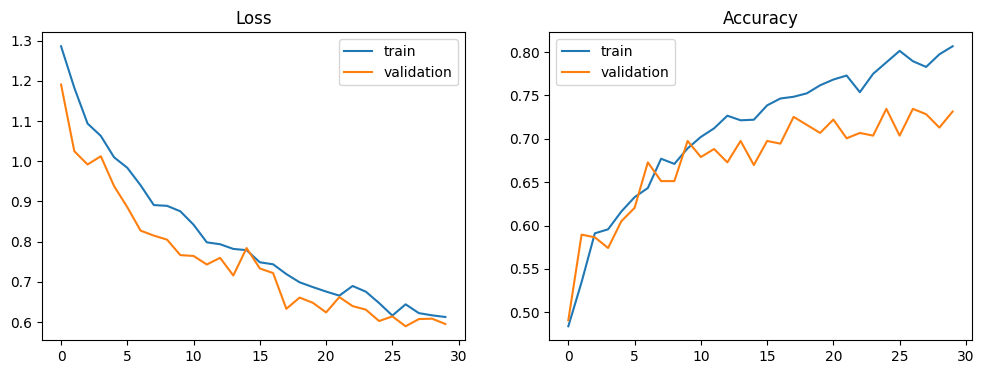

In [11]:
EPOCHS=30; PATIENCE=7
model=build_model(BEST_CFG['dim'],BEST_CFG['grid'],BEST_CFG['heads']).to(DEVICE)
optimizer=torch.optim.AdamW(model.parameters(),lr=BEST_CFG['lr'],weight_decay=1e-4)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=.5,patience=2)
scaler=torch.amp.GradScaler('cuda',enabled=(DEVICE.type=='cuda'))
history={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
best_loss=float('inf'); best_state=None; stale=0
for epoch in range(EPOCHS):
    model.train(); loss_sum=correct=total=0
    for xb,yb in train_loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type,enabled=(DEVICE.type=='cuda')): logits=model(xb); loss=F.cross_entropy(logits,yb,label_smoothing=.05)
        scaler.scale(loss).backward(); scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(),1.0); scaler.step(optimizer); scaler.update()
        loss_sum+=loss.item()*len(yb); correct+=(logits.argmax(1)==yb).sum().item(); total+=len(yb)
    tr_loss=loss_sum/total; tr_acc=correct/total
    model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type,enabled=(DEVICE.type=='cuda')): logits=model(xb); loss=F.cross_entropy(logits,yb)
            vl+=loss.item()*len(yb); vc+=(logits.argmax(1)==yb).sum().item(); vt+=len(yb)
    val_loss=vl/vt; val_acc=vc/vt; scheduler.step(val_loss)
    for k,v in [('train_loss',tr_loss),('val_loss',val_loss),('train_acc',tr_acc),('val_acc',val_acc)]: history[k].append(v)
    print(f'Epoch {epoch+1:02d}: train loss={tr_loss:.4f} acc={tr_acc:.3f} | val loss={val_loss:.4f} acc={val_acc:.3f}')
    if val_loss<best_loss:
        best_loss=val_loss; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}; stale=0
    else:
        stale+=1
        if stale>=PATIENCE: print('Early stopping'); break
model.load_state_dict(best_state); model.eval()
plt.figure(figsize=(12,4)); plt.subplot(1,2,1); plt.plot(history['train_loss'],label='train'); plt.plot(history['val_loss'],label='validation'); plt.legend(); plt.title('Loss')
plt.subplot(1,2,2); plt.plot(history['train_acc'],label='train'); plt.plot(history['val_acc'],label='validation'); plt.legend(); plt.title('Accuracy'); plt.show()

Test accuracy=0.7377 | macro precision=0.7616 | macro recall=0.7480 | macro F1=0.7519 | macro specificity=0.9313
                precision    recall  f1-score   support

   Anthracnose       0.88      0.85      0.87        53
Bacterial Spot       0.60      0.51      0.55        69
          Curl       0.62      0.77      0.69        88
     Ring Spot       0.88      0.79      0.83        80
       Healthy       0.82      0.82      0.82        34

      accuracy                           0.74       324
     macro avg       0.76      0.75      0.75       324
  weighted avg       0.74      0.74      0.74       324



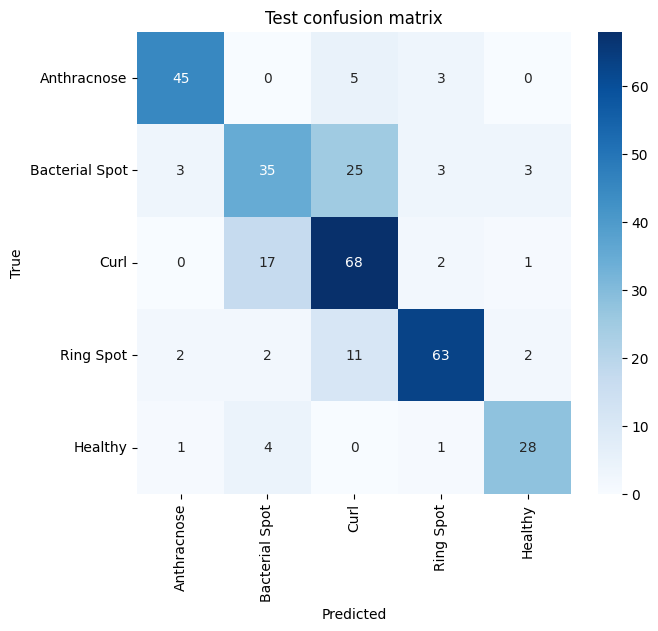

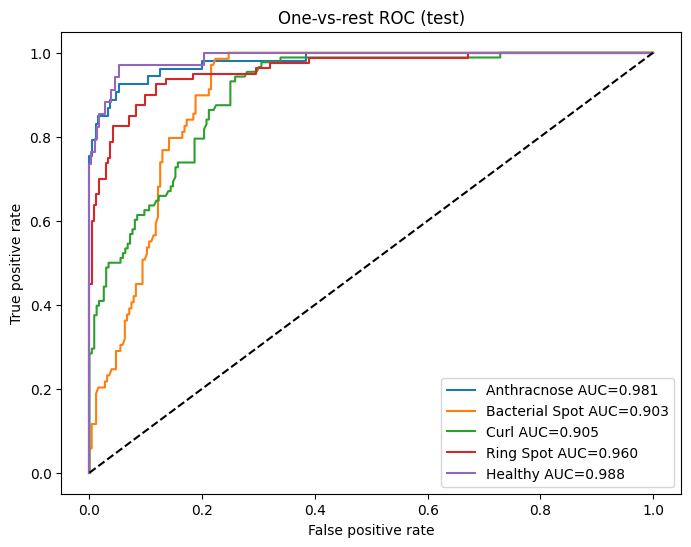

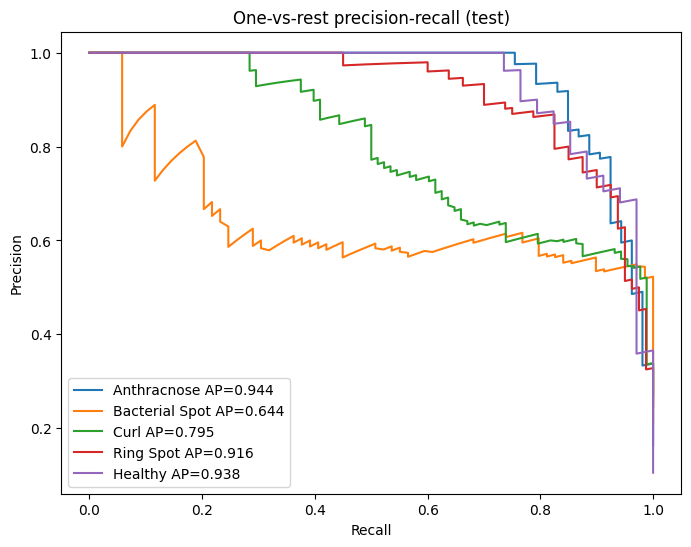

In [12]:
@torch.no_grad()
def predict_loader(loader):
    model.eval(); ys=[]; probs=[]
    for xb,yb in loader:
        xb=xb.to(DEVICE);
        with torch.autocast(device_type=DEVICE.type,enabled=(DEVICE.type=='cuda')): p=model(xb).softmax(1)
        ys.extend(yb.numpy().tolist()); probs.extend(p.float().cpu().numpy())
    return np.array(ys),np.array(probs)
y_test,prob_test=predict_loader(test_loader); pred_test=prob_test.argmax(1)
acc=accuracy_score(y_test,pred_test); precision,recall,f1,_=precision_recall_fscore_support(y_test,pred_test,average='macro',zero_division=0)
cm=confusion_matrix(y_test,pred_test,labels=np.arange(5)); specificity=[]
for i in range(5):
    tp=cm[i,i]; fn=cm[i,:].sum()-tp; fp=cm[:,i].sum()-tp; tn=cm.sum()-tp-fn-fp; specificity.append(tn/max(tn+fp,1))
print(f'Test accuracy={acc:.4f} | macro precision={precision:.4f} | macro recall={recall:.4f} | macro F1={f1:.4f} | macro specificity={np.mean(specificity):.4f}')
print(classification_report(y_test,pred_test,target_names=CLASS_NAMES,zero_division=0))
plt.figure(figsize=(7,6)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES); plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Test confusion matrix'); plt.show()
Y=np.eye(5)[y_test]
plt.figure(figsize=(8,6))
for i,name in enumerate(CLASS_NAMES):
    fpr,tpr,_=roc_curve(Y[:,i],prob_test[:,i]); plt.plot(fpr,tpr,label=f'{name} AUC={auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate'); plt.title('One-vs-rest ROC (test)'); plt.legend(); plt.show()
plt.figure(figsize=(8,6))
for i,name in enumerate(CLASS_NAMES):
    pr,rc,_=precision_recall_curve(Y[:,i],prob_test[:,i]); ap=average_precision_score(Y[:,i],prob_test[:,i]); plt.plot(rc,pr,label=f'{name} AP={ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('One-vs-rest precision-recall (test)'); plt.legend(); plt.show()